# 🗺️ ALIA-CRM — Visit Heat Map *Amélioré*

**Améliorations apportées :**
- ✅ **4 couches visuelles** : heatmap + choroplèthe régions + clusters + top-médecins
- ✅ **KPIs synthétiques** affichés avant la carte
- ✅ **Légende enrichie** avec statistiques live
- ✅ **Popups enrichis** : trend d'intérêt, objection principale, nb de produits distincts
- ✅ **Filtre par niveau d'intérêt minimum** (nouveau slider)
- ✅ **Contrôle des couches** (layer control)
- ✅ **Export HTML automatique**
- ✅ **Visualisation KPI** par région (bar chart)
- ✅ **Correction du bruit GPS** (reproductible par médecin)

In [ ]:
# ============================================================
# ÉTAPE 1 — Installation & imports
# ============================================================
!pip install folium matplotlib seaborn -q

import folium
from folium.plugins import HeatMap, MarkerCluster, Fullscreen, MiniMap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import colorsys  # ✅ FIX 1 — déplacé ici, hors de la boucle
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import base64, json, warnings
warnings.filterwarnings('ignore')

print('✅ Librairies chargées !')


✅ Librairies chargées !


In [ ]:
# ============================================================
# ÉTAPE 2 — Chargement & enrichissement des données
# ============================================================
from google.colab import files
print('📁 Upload : visits_ready_clean_FR.csv')
uploaded = files.upload()

df = pd.read_csv('visits_ready_clean_FR.csv')
print(f'✅ {df.shape[0]} visites | {df.shape[1]} colonnes')

# --- GPS Tunisie (complet) ---
GPS = {
    'Tunis'       : (36.8065, 10.1815),
    'Sfax'        : (34.7406, 10.7603),
    'Sousse'      : (35.8245, 10.6346),
    'Bizerte'     : (37.2744,  9.8739),
    'Monastir'    : (35.7643, 10.8113),
    'Nabeul'      : (36.4513, 10.7357),
    'Ariana'      : (36.8625, 10.1956),
    'Ben Arous'   : (36.7531, 10.2282),
    'Manouba'     : (36.8089, 10.0986),
    'Gabès'       : (33.8881, 10.0975),
    'Kairouan'    : (35.6781, 10.0964),
    'Gafsa'       : (34.4250,  8.7842),
    'Médenine'    : (33.3549, 10.5055),
    'Jendouba'    : (36.5011,  8.7757),
    'Kasserine'   : (35.1676,  8.8365),
    'Zaghouan'    : (36.4029, 10.1429),
    # ✅ FIX 2 — Régions manquantes ajoutées
    'Siliana'     : (36.0847,  9.3708),
    'Sidi Bouzid' : (35.0382,  9.4858),
    'Tataouine'   : (32.9211, 10.4511),
    'Tozeur'      : (33.9197,  8.1335),
    'Kébili'      : (33.7050,  8.9650),
    'Béja'        : (36.7256,  9.1817),
    'Le Kef'      : (36.1675,  8.7147),
}

df['latitude']  = df['region_clean'].map(lambda r: GPS.get(r, (34.0, 9.5))[0])
df['longitude'] = df['region_clean'].map(lambda r: GPS.get(r, (34.0, 9.5))[1])

# Bruit reproductible par médecin (stable entre appels)
rng = np.random.default_rng(seed=42)
doctor_offsets = {}
for doc in df['nom_medecin'].unique():
    doctor_offsets[doc] = (rng.uniform(-0.05, 0.05), rng.uniform(-0.05, 0.05))

df['latitude']  += df['nom_medecin'].map(lambda d: doctor_offsets[d][0])
df['longitude'] += df['nom_medecin'].map(lambda d: doctor_offsets[d][1])
df['heat_score'] = df['niveau_interet']

# Tendance d'intérêt par médecin (premier vs dernier tiers des visites)
df['visit_idx'] = df.groupby('nom_medecin').cumcount()
total_visits_per_doc = df.groupby('nom_medecin')['visit_idx'].transform('max') + 1
df['visit_pct'] = df['visit_idx'] / total_visits_per_doc
early = df[df['visit_pct'] < 0.33].groupby('nom_medecin')['niveau_interet'].mean()
late  = df[df['visit_pct'] > 0.67].groupby('nom_medecin')['niveau_interet'].mean()
trend = (late - early).rename('interet_trend')
df = df.join(trend, on='nom_medecin')

# Vérification des régions non mappées
regions_non_mappees = set(df['region_clean'].dropna().unique()) - set(GPS.keys())
if regions_non_mappees:
    print(f'⚠️ Régions sans coordonnées GPS : {regions_non_mappees}')
else:
    print('✅ Toutes les régions sont mappées GPS')

print(f'\n📍 Régions :', df['region_clean'].value_counts().to_dict())
print(f'\n🏥 Spécialités :', df['specialite_medecin'].nunique())


📁 Upload : visits_ready_clean_FR.csv


Saving visits_ready_clean_FR.csv to visits_ready_clean_FR.csv
✅ 4142 visites | 19 colonnes
✅ Toutes les régions sont mappées GPS

📍 Régions : {'Nabeul': 501, 'Ariana': 485, 'Bizerte': 472, 'Ben Arous': 461, 'Sfax': 453, 'Monastir': 452, 'Manouba': 448, 'Tunis': 444, 'Sousse': 426}

🏥 Spécialités : 14


In [ ]:
# ============================================================
# ÉTAPE 3 — KPI Dashboard (avant la carte)
# ============================================================

def print_kpis(df_f, label='Global'):
    nb_v = len(df_f)
    nb_m = df_f['nom_medecin'].nunique()
    avg_i = df_f['niveau_interet'].mean()
    pct_high = (df_f['niveau_interet'] >= 4).mean() * 100
    top_prod = df_f['medicament'].value_counts().index[0] if nb_v > 0 else 'N/A'
    top_obj  = df_f['objection_clean'].value_counts().index[0] if df_f['objection_clean'].notna().any() else 'N/A'

    html = f"""
    <div style="display:flex;gap:12px;flex-wrap:wrap;margin:12px 0;font-family:Arial">
      <div style="background:#1a1a2e;color:white;padding:14px 20px;border-radius:10px;min-width:120px;text-align:center">
        <div style="font-size:22px;font-weight:bold">{nb_v:,}</div>
        <div style="font-size:11px;opacity:.8">Visites</div>
      </div>
      <div style="background:#16213e;color:white;padding:14px 20px;border-radius:10px;min-width:120px;text-align:center">
        <div style="font-size:22px;font-weight:bold">{nb_m}</div>
        <div style="font-size:11px;opacity:.8">Médecins</div>
      </div>
      <div style="background:#0f3460;color:white;padding:14px 20px;border-radius:10px;min-width:120px;text-align:center">
        <div style="font-size:22px;font-weight:bold">{avg_i:.2f}/5</div>
        <div style="font-size:11px;opacity:.8">Intérêt moyen</div>
      </div>
      <div style="background:#533483;color:white;padding:14px 20px;border-radius:10px;min-width:120px;text-align:center">
        <div style="font-size:22px;font-weight:bold">{pct_high:.0f}%</div>
        <div style="font-size:11px;opacity:.8">Intérêt ≥ 4/5</div>
      </div>
      <div style="background:#e94560;color:white;padding:14px 20px;border-radius:10px;min-width:140px;text-align:center">
        <div style="font-size:13px;font-weight:bold">{top_prod}</div>
        <div style="font-size:11px;opacity:.8">Top produit</div>
      </div>
      <div style="background:#b5451b;color:white;padding:14px 20px;border-radius:10px;min-width:180px;text-align:center">
        <div style="font-size:11px;font-weight:bold">{top_obj[:35]}</div>
        <div style="font-size:11px;opacity:.8">Objection principale</div>
      </div>
    </div>
    """
    display(HTML(f'<b style="font-family:Arial">📊 KPIs — {label}</b>' + html))

print_kpis(df, 'Toutes les données')

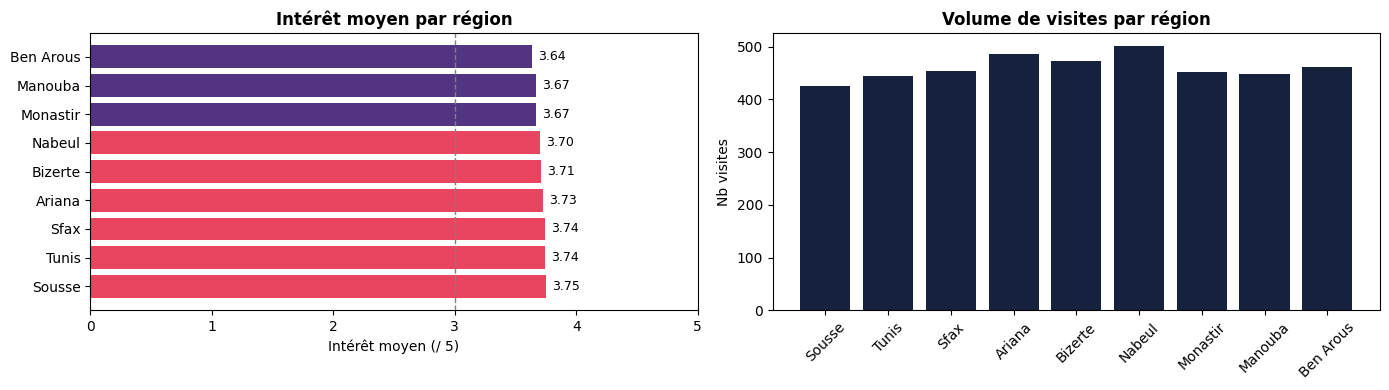

In [ ]:
# ============================================================
# ÉTAPE 4 — Bar chart : Intérêt moyen par région
# ============================================================

def plot_region_chart(df_f):
    reg_stats = df_f.groupby('region_clean').agg(
        avg_interet = ('niveau_interet', 'mean'),
        nb_visites  = ('nom_medecin', 'count'),
        pct_high    = ('niveau_interet', lambda x: (x >= 4).mean() * 100)
    ).sort_values('avg_interet', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    colors = ['#e94560' if v >= 3.7 else '#533483' if v >= 3.3 else '#0f3460'
              for v in reg_stats['avg_interet']]

    axes[0].barh(reg_stats.index, reg_stats['avg_interet'], color=colors, edgecolor='none')
    axes[0].axvline(3, color='gray', linestyle='--', lw=1, label='Seuil moyen')
    axes[0].set_xlabel('Intérêt moyen (/ 5)')
    axes[0].set_title('Intérêt moyen par région', fontweight='bold')
    axes[0].set_xlim(0, 5)
    for i, (r, row) in enumerate(reg_stats.iterrows()):
        axes[0].text(row['avg_interet'] + 0.05, i, f"{row['avg_interet']:.2f}", va='center', fontsize=9)

    axes[1].bar(reg_stats.index, reg_stats['nb_visites'], color='#16213e', edgecolor='none')
    axes[1].set_ylabel('Nb visites')
    axes[1].set_title('Volume de visites par région', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

plot_region_chart(df)

In [ ]:
# ============================================================
# ÉTAPE 5 — Fonction show_map (affichage Colab)
# ============================================================

def show_map(m, height=600):
    m.save('heatmap.html')
    with open('heatmap.html', 'r', encoding='utf-8') as f:
        b64 = base64.b64encode(f.read().encode()).decode()
    display(HTML(f'''
        <iframe src="data:text/html;base64,{b64}"
                width="100%" height="{height}px"
                frameborder="0"
                style="border-radius:12px;box-shadow:0 4px 20px rgba(0,0,0,0.25);">
        </iframe>
    '''))

In [ ]:
# ============================================================
# ÉTAPE 6 — Génération de la carte améliorée
# ============================================================

GRADIENT = {
    '0.0': '#313695',
    '0.25': '#74add1',
    '0.5': '#fee090',
    '0.75': '#f46d43',
    '1.0': '#d73027'
}

def get_trend_icon(trend_val):
    if pd.isna(trend_val): return '➡️'
    if trend_val >  0.3: return '📈'
    if trend_val < -0.3: return '📉'
    return '➡️'

def get_engagement_label(avg):
    if avg >= 4.0: return '🔥 Très engagé'
    if avg >= 3.0: return '⭐ Engagé'
    if avg >= 2.0: return '❄️ Faible'
    return '⚠️ Très faible'

def marker_color(avg):
    if avg >= 4.0: return 'red'
    if avg >= 3.0: return 'orange'
    if avg >= 2.0: return 'blue'
    return 'gray'


def generate_heatmap_v2(filtre_spec='Toutes', filtre_prod='Tous',
                        filtre_region='Toutes', min_interet=1, show_kpis=True):  # ✅ FIX 4

    df_f = df.copy()
    if filtre_spec != 'Toutes':
        df_f = df_f[df_f['specialite_medecin'] == filtre_spec]
    if filtre_prod != 'Tous':
        df_f = df_f[df_f['medicament'] == filtre_prod]
    if filtre_region != 'Toutes':  # ✅ FIX 4
        df_f = df_f[df_f['region_clean'] == filtre_region]
    df_f = df_f[df_f['niveau_interet'] >= min_interet]

    if df_f.empty:
        print('❌ Aucune donnée pour ces filtres.')
        return

    label = f"{'Global' if filtre_spec == 'Toutes' else filtre_spec}"
    if filtre_prod != 'Tous': label += f' | {filtre_prod}'
    if min_interet > 1: label += f' | Intérêt ≥ {min_interet}'

    if show_kpis:
        print_kpis(df_f, label)
        plot_region_chart(df_f)

    # ── Carte de base ───────────────────────────────────────────
    m = folium.Map(
        location=[34.8, 9.8], zoom_start=7,
        tiles='CartoDB positron'
    )

    # ── Plugin : plein écran & mini-carte ───────────────────────
    Fullscreen(position='topright').add_to(m)
    MiniMap(toggle_display=True).add_to(m)

    # ── COUCHE 1 : HeatMap (intérêt pondéré) ────────────────────
    heat_data = [[r['latitude'], r['longitude'], r['heat_score']]
                 for _, r in df_f.iterrows()]
    HeatMap(
        heat_data,
        name='🔥 Heatmap (intensité)',
        min_opacity=0.35,
        radius=28,
        blur=18,
        gradient=GRADIENT
    ).add_to(m)

    # ── COUCHE 2 : Choroplèthe régions (cercles proportionnels) ─
    region_layer = folium.FeatureGroup(name='🗺️ Régions (volume)')
    reg_stats = df_f.groupby('region_clean').agg(
        lat=('latitude','mean'), lon=('longitude','mean'),
        nb=('nom_medecin','count'),
        avg=('niveau_interet','mean')
    ).reset_index()

    max_nb = reg_stats['nb'].max()
    for _, r in reg_stats.iterrows():
        radius = 15000 * (r['nb'] / max_nb) ** 0.5  # rayon géo en mètres
        # couleur basée sur intérêt moyen (bleu→rouge)
        norm = (r['avg'] - 1) / 4
        import colorsys
        h = (1 - norm) * 0.66  # hue: 0.66=bleu, 0=rouge
        rgb = colorsys.hsv_to_rgb(h, 0.8, 0.9)
        hex_color = '#{:02x}{:02x}{:02x}'.format(*[int(x*255) for x in rgb])

        folium.Circle(
            location=[GPS.get(r['region_clean'], (34,9.5))[0],
                      GPS.get(r['region_clean'], (34,9.5))[1]],
            radius=radius,
            color=hex_color,
            fill=True, fill_opacity=0.25,
            weight=2,
            tooltip=(
                f"<b>{r['region_clean']}</b><br>"
                f"{r['nb']} visites | Intérêt moy. {r['avg']:.2f}/5"
            )
        ).add_to(region_layer)

        folium.Marker(
            location=[GPS.get(r['region_clean'], (34,9.5))[0],
                      GPS.get(r['region_clean'], (34,9.5))[1]],
            icon=folium.DivIcon(
                html=f'<div style="font-size:10px;font-weight:bold;color:#333;white-space:nowrap;">'
                     f'{r["region_clean"]}<br><span style="color:{hex_color}">{r["avg"]:.1f}★</span></div>',
                icon_size=(80, 30),
                icon_anchor=(40, 0)
            )
        ).add_to(region_layer)

    region_layer.add_to(m)

    # ── COUCHE 3 : Clusters de médecins (enrichis) ──────────────
    cluster_layer = folium.FeatureGroup(name='👨‍⚕️ Médecins (détail)')
    cluster = MarkerCluster().add_to(cluster_layer)

    doc_sum = df_f.groupby('nom_medecin').agg(
        specialite    = ('specialite_medecin', 'first'),
        region        = ('region_clean', 'first'),
        lat           = ('latitude', 'mean'),
        lon           = ('longitude', 'mean'),
        nb_visites    = ('nom_medecin', 'count'),
        avg_interet   = ('niveau_interet', 'mean'),
        nb_produits   = ('medicament', 'nunique'),
        top_produit   = ('medicament', lambda x: x.value_counts().index[0]),
        top_objection = ('objection_clean', lambda x: x.value_counts().index[0]
                         if len(x.dropna())>0 else 'N/A'),
        trend         = ('interet_trend', 'first'),
    ).reset_index()

    for _, r in doc_sum.iterrows():
        trend_icon = get_trend_icon(r['trend'])
        engagement = get_engagement_label(r['avg_interet'])
        color = marker_color(r['avg_interet'])

        popup_html = f"""
        <div style="font-family:Arial;width:250px;padding:12px;">
            <h4 style="color:#1a1a2e;margin:0 0 6px">👨‍⚕️ {r['nom_medecin']}</h4>
            <hr style="margin:4px 0;border-color:#eee">
            <table style="width:100%;font-size:12px;">
              <tr><td>🏥 Spécialité</td><td><b>{r['specialite']}</b></td></tr>
              <tr><td>📍 Région</td><td><b>{r['region']}</b></td></tr>
              <tr><td>💊 Top Produit</td><td><b>{r['top_produit']}</b></td></tr>
              <tr><td>💊 Nb Produits vus</td><td><b>{r['nb_produits']}</b></td></tr>
              <tr><td>⚠️ Objection fréq.</td><td><b>{r['top_objection'][:30]}</b></td></tr>
            </table>
            <hr style="margin:6px 0;border-color:#eee">
            <table style="width:100%;font-size:12px;">
              <tr><td>📅 Nb Visites</td><td><b>{r['nb_visites']}</b></td></tr>
              <tr><td>⭐ Intérêt moyen</td><td><b>{r['avg_interet']:.2f}/5</b></td></tr>
              <tr><td>📈 Tendance</td><td><b>{trend_icon} ({r['trend']:+.2f})</b></td></tr>
              <tr><td>🎯 Engagement</td><td><b>{engagement}</b></td></tr>
            </table>
        </div>
        """
        folium.Marker(
            location=[r['lat'], r['lon']],
            popup=folium.Popup(popup_html, max_width=270),
            tooltip=f"👨‍⚕️ {r['nom_medecin']} — {r['region']} ({r['avg_interet']:.1f}/5) {trend_icon}",
            icon=folium.Icon(color=color, icon='plus-sign', prefix='glyphicon')
        ).add_to(cluster)

    cluster_layer.add_to(m)

    # ── COUCHE 4 : Top médecins (intérêt ≥ 4.5) ─────────────────
    top_layer = folium.FeatureGroup(name='🏆 Top médecins (≥4.5/5)', show=True)
    top_docs = doc_sum[doc_sum['avg_interet'] >= 4.5]
    for _, r in top_docs.iterrows():
        folium.CircleMarker(
            location=[r['lat'], r['lon']],
            radius=14,
            color='#d73027',
            fill=True, fill_color='#d73027', fill_opacity=0.85,
            tooltip=f"🏆 {r['nom_medecin']} | {r['avg_interet']:.2f}/5"
        ).add_to(top_layer)
    top_layer.add_to(m)

    # ── Contrôle des couches ────────────────────────────────────
    folium.LayerControl(collapsed=False).add_to(m)

    # ── Légende enrichie ────────────────────────────────────────
    pct_high = (df_f['niveau_interet'] >= 4).mean() * 100
    legend_html = f"""
    <div style="position:fixed;bottom:30px;left:10px;z-index:9999;
                background:white;padding:14px;border-radius:12px;
                box-shadow:2px 2px 10px rgba(0,0,0,0.25);
                font-family:Arial;font-size:12px;max-width:200px;">
      <b>🔥 Niveau d'intérêt</b><br><br>
      <span style="color:#d73027">●</span> Très élevé (≥4/5)<br>
      <span style="color:#f46d43">●</span> Élevé (3-4/5)<br>
      <span style="color:#74add1">●</span> Moyen (2-3/5)<br>
      <span style="color:#313695">●</span> Faible (&lt;2/5)<br>
      <hr style="margin:8px 0">
      <b>Tendance</b><br>
      📈 Intérêt croissant<br>
      📉 Intérêt décroissant<br>
      ➡️ Stable<br>
      <hr style="margin:8px 0">
      <small>
        📊 <b>{len(df_f):,}</b> visites<br>
        👨‍⚕️ <b>{len(doc_sum)}</b> médecins<br>
        ⭐ Moy : <b>{df_f['niveau_interet'].mean():.2f}/5</b><br>
        🔥 <b>{pct_high:.0f}%</b> intérêt élevé
      </small>
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))

    # ── Titre dynamique ─────────────────────────────────────────
    titre = f'🗺️ ALIA-CRM — {label}'
    m.get_root().html.add_child(folium.Element(f"""
    <div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);
                z-index:9999;background:#1a1a2e;color:white;
                padding:10px 24px;border-radius:10px;
                font-family:Arial;font-size:14px;font-weight:bold;">
        {titre}
    </div>
    """))

    print(f'✅ Carte générée — {len(df_f):,} visites | {len(doc_sum)} médecins | intérêt moy. {df_f["niveau_interet"].mean():.2f}/5')
    show_map(m, height=620)


# Test rapide — carte globale
generate_heatmap_v2(show_kpis=False)

✅ Carte générée — 4,142 visites | 10 médecins | intérêt moy. 3.71/5


In [ ]:
# ============================================================
# ÉTAPE 7 — Widget interactif (filtres + slider intérêt)
# ============================================================

specialites = ['Toutes'] + sorted(df['specialite_medecin'].dropna().unique().tolist())
produits    = ['Tous']   + sorted(df['medicament'].dropna().unique().tolist())
# ✅ FIX 4 — Filtre région ajouté
regions     = ['Toutes'] + sorted(df['region_clean'].dropna().unique().tolist())

w_spec = widgets.Dropdown(
    options=specialites, value='Toutes',
    description='🏥 Spécialité :',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='380px'))

w_prod = widgets.Dropdown(
    options=produits, value='Tous',
    description='💊 Produit :',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='380px'))

w_region = widgets.Dropdown(
    options=regions, value='Toutes',
    description='📍 Région :',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='380px'))

w_min_interet = widgets.IntSlider(
    value=1, min=1, max=5, step=1,
    description='⭐ Intérêt min :',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='380px'))

w_kpis = widgets.Checkbox(
    value=True, description='Afficher KPIs + graphique')

btn = widgets.Button(
    description='🗺️ Générer la carte',
    button_style='success',
    layout=widgets.Layout(width='260px', height='42px'))

out = widgets.Output()

def on_click(b):
    with out:
        clear_output()
        generate_heatmap_v2(
            filtre_spec=w_spec.value,
            filtre_prod=w_prod.value,
            filtre_region=w_region.value,  # ✅ FIX 4
            min_interet=w_min_interet.value,
            show_kpis=w_kpis.value
        )

btn.on_click(on_click)

print('=' * 60)
print('  🗺️  ALIA-CRM — Heat Map Améliorée  |  LIVE DEMO')
print('=' * 60)
display(widgets.VBox([
    w_spec, w_prod, w_region, w_min_interet, w_kpis, btn, out  # ✅ FIX 4
]))

  🗺️  ALIA-CRM — Heat Map Améliorée  |  LIVE DEMO


In [ ]:
# ============================================================
# ÉTAPE 8 — Analyse complémentaire : Top médecins à risque
# (tendance négative + intérêt moyen > 3 = à reconquérir)
# ============================================================

# ✅ FIX 3 — Filtrer les médecins avec assez de visites pour calculer une tendance fiable
MIN_VISITES_TREND = 3

doc_full = df.groupby('nom_medecin').agg(
    specialite   = ('specialite_medecin', 'first'),
    region       = ('region_clean', 'first'),
    nb_visites   = ('nom_medecin', 'count'),
    avg_interet  = ('niveau_interet', 'mean'),
    trend        = ('interet_trend', 'first'),
    top_produit  = ('medicament', lambda x: x.value_counts().index[0]),
).reset_index()

# ✅ FIX 3 — Appliquer le filtre minimum de visites
doc_full_filtered = doc_full[doc_full['nb_visites'] >= MIN_VISITES_TREND]

# Médecins à risque : intérêt > 3 MAIS trend négatif
at_risk = doc_full_filtered[
    (doc_full_filtered['avg_interet'] >= 3.0) &
    (doc_full_filtered['trend'] < -0.3)
].sort_values('trend').head(10)

print(f'\n⚠️  {len(at_risk)} médecins à risque (intérêt moyen ≥3 mais tendance négative):')
display(at_risk[['nom_medecin','specialite','region','avg_interet','trend','top_produit','nb_visites']]
        .style
        .background_gradient(subset=['avg_interet'], cmap='RdYlGn', vmin=1, vmax=5)
        .background_gradient(subset=['trend'], cmap='RdYlGn_r', vmin=-1, vmax=0)
        .format({'avg_interet': '{:.2f}', 'trend': '{:+.2f}'})
        .set_caption('🚨 Médecins à reconquérir en priorité'))

# Top 10 médecins à fort potentiel (intérêt élevé + tendance positive)
top_potential = doc_full_filtered[
    (doc_full_filtered['avg_interet'] >= 3.5) &
    (doc_full_filtered['trend'] > 0.2)
].sort_values(['avg_interet', 'trend'], ascending=False).head(10)

print(f'\n🚀  {len(top_potential)} médecins à fort potentiel (intérêt ≥3.5 + tendance positive):')
display(top_potential[['nom_medecin','specialite','region','avg_interet','trend','top_produit','nb_visites']]
        .style
        .background_gradient(subset=['avg_interet'], cmap='RdYlGn', vmin=1, vmax=5)
        .background_gradient(subset=['trend'], cmap='RdYlGn', vmin=0, vmax=1)
        .format({'avg_interet': '{:.2f}', 'trend': '{:+.2f}'})
        .set_caption('🚀 Médecins à fort potentiel — prioriser les visites'))

# ✅ FIX 5 — Export CSV pour intégration dans la plateforme
at_risk.to_csv('medecins_a_risque.csv', index=False)
top_potential.to_csv('medecins_top_potentiel.csv', index=False)

from google.colab import files
files.download('medecins_a_risque.csv')
files.download('medecins_top_potentiel.csv')
print("\n✅ Export réussi — fichiers prêts pour l'intégration dans la plateforme")



⚠️  1 médecins à risque (intérêt moyen ≥3 mais tendance négative):


,nom_medecin,specialite,region,avg_interet,trend,top_produit,nb_visites
6,Dr Rania Khelifi,Dermatologie,Sfax,3.75,-0.32,propecia,414



🚀  0 médecins à fort potentiel (intérêt ≥3.5 + tendance positive):


,nom_medecin,specialite,region,avg_interet,trend,top_produit,nb_visites


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Export réussi — fichiers prêts pour l'intégration dans la plateforme
